# Data Preprocessing

## 1. Introduction

This notebook prepares the cleaned single-family residential property data for modeling.

The data is restricted to transactions from January 2024 onward because the earlier months have inconsistent record coverage. The dataset is then divided chronologically into training, validation, and test sets.

- Training set: January 2024 through March 2026
- Validation set: April 2026
- Test set: May 2026

A chronological split is used instead of a random split to ensure that the model is trained on historical data and evaluated on future transactions.

## 2. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


## 3. Load the Cleaned Dataset

The cleaned dataset produced by the data cleaning notebook is loaded below. Date columns are converted to datetime format during loading.

In [2]:
file_path = "../data/processed/crmls_sfr_cleaned_base.csv"

df = pd.read_csv(
    file_path,
    dtype={
        "ListingKey": "string",
        "ListingId": "string",
        "PostalCode": "string",
        "source_period": "string",
        "close_month": "string"
    },
    parse_dates=[
        "CloseDate",
        "ListingContractDate",
        "PurchaseContractDate",
        "ContractStatusChangeDate",
        "source_month"
    ],
    low_memory=False
)

print(f"Dataset shape: {df.shape[0]:,} rows and {df.shape[1]} columns")
print(f"Close date range: {df['CloseDate'].min().date()} to {df['CloseDate'].max().date()}")

Dataset shape: 398,461 rows and 70 columns
Close date range: 2022-01-01 to 2026-05-31


## 4. Select the Modeling Period

Only transactions closed on or after January 1, 2024 are retained for the initial modeling dataset. This period has more consistent monthly record coverage than the earlier data.

In [3]:
monthly_counts = (
    df.groupby(df["CloseDate"].dt.to_period("M"))
      .size()
      .rename("row_count")
      .reset_index()
)

monthly_counts

,CloseDate,row_count
0,2022-01,2310
1,2022-02,1224
2,2022-03,868
3,2022-04,405
4,2022-05,229
5,2022-06,170
6,2022-07,100
7,2022-08,71
8,2022-09,50
9,2022-10,36


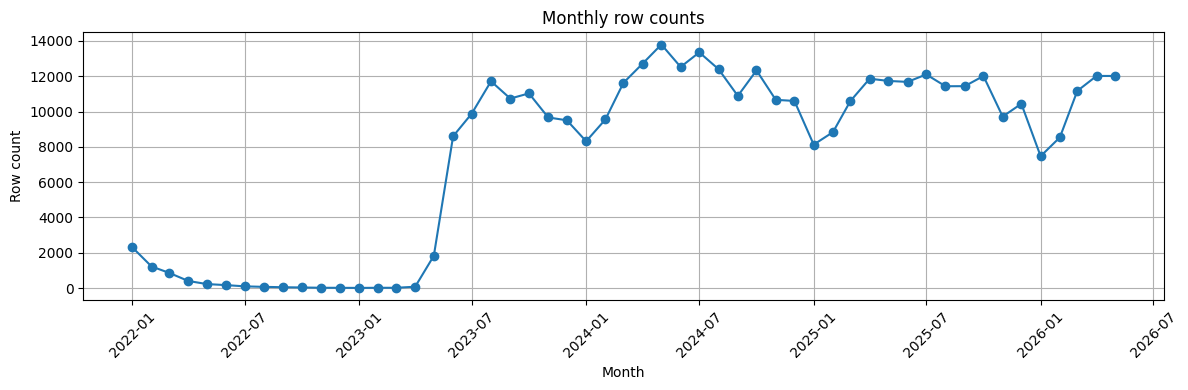

In [4]:
plt.figure(figsize=(12, 4))
x = monthly_counts["CloseDate"].dt.to_timestamp()
y = monthly_counts["row_count"]
plt.plot(x, y, marker="o")
plt.xlabel("Month")
plt.ylabel("Row count")
plt.title("Monthly row counts")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
modeling_start_date = pd.Timestamp("2024-01-01")

df_model = df.loc[
    df["CloseDate"] >= modeling_start_date
].copy()

print(f"Rows before date filtering: {len(df):,}")
print(f"Rows after date filtering:  {len(df_model):,}")
print(f"Rows excluded:              {len(df) - len(df_model):,}")

print(
    f"Modeling date range:        "
    f"{df_model['CloseDate'].min().date()} to "
    f"{df_model['CloseDate'].max().date()}"
)

Rows before date filtering: 398,461
Rows after date filtering:  319,884
Rows excluded:              78,577
Modeling date range:        2024-01-01 to 2026-05-31


## 5. Chronological Train, Validation, and Test Split

The dataset is divided chronologically without shuffling.

The most recent complete month, May 2026, is used as the test set. April 2026 is reserved as the validation set, while all selected earlier months are used for training.

In [6]:
validation_start = pd.Timestamp("2026-04-01")
test_start = pd.Timestamp("2026-05-01")
test_end = pd.Timestamp("2026-06-01")

train_df = df_model.loc[df_model["CloseDate"] < validation_start].copy()

validation_df = df_model.loc[(df_model["CloseDate"] >= validation_start) & (df_model["CloseDate"] < test_start)].copy()

test_df = df_model.loc[(df_model["CloseDate"] >= test_start) & (df_model["CloseDate"] < test_end)].copy()

Check the division result:

In [7]:
train_min_date = train_df["CloseDate"].min()
train_max_date = train_df["CloseDate"].max()

validation_min_date = validation_df["CloseDate"].min()
validation_max_date = validation_df["CloseDate"].max()

test_min_date = test_df["CloseDate"].min()
test_max_date = test_df["CloseDate"].max()

summary_data = {
    "Split": ["Train", "Validation", "Test"],
    "Start Date": [train_min_date, validation_min_date, test_min_date],
    "End Date": [train_max_date, validation_max_date, test_max_date],
    "Rows": [len(train_df), len(validation_df), len(test_df)]
}

split_summary = pd.DataFrame(summary_data)
split_summary

,Split,Start Date,End Date,Rows
0,Train,2024-01-01,2026-03-31,295857
1,Validation,2026-04-01,2026-04-30,12014
2,Test,2026-05-01,2026-05-31,12013


## 6. Feature Selection and Leakage Prevention

`ClosePrice` is the target variable.

The initial feature set contains intrinsic property characteristics and location-related variables that would be available before the final sale price is known.

Listing prices, days on market, transaction dates, agent information, record identifiers, and other sale-process variables are excluded to prevent target leakage.

Latitude and longitude are not included in the initial model because their availability is inconsistent across the source files.

In [8]:
train_df.columns

Index(['source_period', 'source_file', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'CloseDate', 'ClosePrice', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'YearBuilt', 'BuyerAgencyCompensationType',
       'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City',
       'BuyerAgencyCompensation', 'TaxYear', 'BuildingAreaTotal',
       'BedroomsTotal', 'ContractStatusChangeDate', 'ElementarySchoolDistrict',
       'PurchaseContractDate', 'ListingContractDate', 'BelowGradeFinishedArea',
       'BusinessType', 'StateOrProvince',

Define target variable, and features.

In [9]:
target = "ClosePrice"

numeric_features = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "GarageSpaces",
    "ParkingTotal",
    "Stories"
]

categorical_features = [
    "PostalCode",
    "CountyOrParish",
    "MLSAreaMajor",
    "Levels",
    "PoolPrivateYN",
    "ViewYN",
    "AttachedGarageYN",
    "NewConstructionYN",
    "FireplaceYN"
]

In [10]:
feature_columns = numeric_features + categorical_features

print(f"Target variable: {target}")
print(f"Number of numeric features: {len(numeric_features)}")
print(f"Number of categorical features: {len(categorical_features)}")
print(f"Total number of input features: {len(feature_columns)}")

Target variable: ClosePrice
Number of numeric features: 8
Number of categorical features: 9
Total number of input features: 17


In [11]:
X_train = train_df[feature_columns].copy()
y_train = train_df[target].copy()

X_validation = validation_df[feature_columns].copy()
y_validation = validation_df[target].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target].copy()

## 7. Training-Based ClosePrice Outlier Treatment

Statistical outlier thresholds are calculated using the training target only.

The 0.5th and 99.5th percentiles of training ClosePrice are used as the lower and upper bounds. The same fixed thresholds are then applied to the training, validation, and test sets to avoid using information from future data.

In [12]:
lower_price_bound = y_train.quantile(0.005)
upper_price_bound = y_train.quantile(0.995)

print(f"Lower ClosePrice bound: ${lower_price_bound:,.0f}")
print(f"Upper ClosePrice bound: ${upper_price_bound:,.0f}")

Lower ClosePrice bound: $190,000
Upper ClosePrice bound: $8,247,200


In [13]:
train_price_mask = y_train.between(
    lower_price_bound,
    upper_price_bound,
    inclusive="both"
)

validation_price_mask = y_validation.between(
    lower_price_bound,
    upper_price_bound,
    inclusive="both"
)

test_price_mask = y_test.between(
    lower_price_bound,
    upper_price_bound,
    inclusive="both"
)

In [14]:
outlier_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Rows Before": [
        len(y_train),
        len(y_validation),
        len(y_test)
    ],
    "Rows Removed": [
        (~train_price_mask).sum(),
        (~validation_price_mask).sum(),
        (~test_price_mask).sum()
    ]
})

outlier_summary["Rows After"] = (
    outlier_summary["Rows Before"]
    - outlier_summary["Rows Removed"]
)

outlier_summary["Percentage Removed"] = (
    outlier_summary["Rows Removed"]
    / outlier_summary["Rows Before"]
    * 100
)

outlier_summary

,Split,Rows Before,Rows Removed,Rows After,Percentage Removed
0,Train,295857,2937,292920,0.992709
1,Validation,12014,134,11880,1.115365
2,Test,12013,124,11889,1.032215


In [15]:
X_train = (
    X_train.loc[train_price_mask]
    .reset_index(drop=True)
)

y_train = (
    y_train.loc[train_price_mask]
    .reset_index(drop=True)
)

X_validation = (
    X_validation.loc[validation_price_mask]
    .reset_index(drop=True)
)

y_validation = (
    y_validation.loc[validation_price_mask]
    .reset_index(drop=True)
)

X_test = (
    X_test.loc[test_price_mask]
    .reset_index(drop=True)
)

y_test = (
    y_test.loc[test_price_mask]
    .reset_index(drop=True)
)

## 8. Missing-Value Inspection

Missing values are examined separately in the training, validation, and test sets.

This comparison helps determine whether missingness is stable over time and guides the imputation strategy. No values are imputed during this step.

In [16]:
def missing_summary(data, split_name):
    summary = pd.DataFrame({
        "Feature": data.columns,
        f"{split_name} Missing Count": data.isna().sum().values,
        f"{split_name} Missing Rate": (
            data.isna().mean().values * 100
        )
    })

    return summary


train_missing = missing_summary(X_train, "Train")
validation_missing = missing_summary(
    X_validation,
    "Validation"
)
test_missing = missing_summary(X_test, "Test")

In [17]:
missing_value_summary = (
    train_missing
    .merge(
        validation_missing,
        on="Feature",
        how="outer"
    )
    .merge(
        test_missing,
        on="Feature",
        how="outer"
    )
)

missing_value_summary = (
    missing_value_summary
    .sort_values(
        "Train Missing Rate",
        ascending=False
    )
    .reset_index(drop=True)
)

missing_value_summary

,Feature,Train Missing Count,Train Missing Rate,Validation Missing Count,Validation Missing Rate,Test Missing Count,Test Missing Rate
0,MLSAreaMajor,41711,14.239724,1732,14.579125,1827,15.367146
1,Stories,37188,12.695617,1303,10.968013,1318,11.085878
2,AttachedGarageYN,33020,11.272702,1457,12.264310,1379,11.598957
3,PoolPrivateYN,28083,9.587259,985,8.291246,1029,8.655059
4,Levels,27925,9.533320,959,8.072391,994,8.360670
5,ViewYN,26376,9.004506,1054,8.872054,1138,9.571873
6,NewConstructionYN,21363,7.293118,913,7.685185,935,7.864412
7,GarageSpaces,10480,3.577769,414,3.484848,453,3.810245
8,LotSizeSquareFeet,5174,1.766353,237,1.994949,209,1.757927
9,ParkingTotal,422,0.144067,0,0.000000,2,0.016822


The missingness rates do not differ significantly.

In [18]:
for feature in categorical_features:
    print(f"\n{feature}")
    print(
        X_train[feature]
        .value_counts(dropna=False)
        .head(15)
    )


PostalCode
PostalCode
92253    2069
92223    1698
92345    1644
92584    1642
92596    1534
92592    1528
92562    1377
93536    1330
92211    1313
92336    1280
92392    1249
94513    1242
92563    1241
92308    1177
92203    1129
Name: count, dtype: Int64

CountyOrParish
CountyOrParish
Los Angeles        70853
Riverside          44596
San Diego          31673
San Bernardino     31241
Orange             27442
Alameda            14169
Contra Costa       13758
Santa Clara        12124
Ventura             9176
San Mateo           5094
San Luis Obispo     4776
Monterey            3222
Butte               3203
Kern                3041
Merced              2369
Name: count, dtype: int64

MLSAreaMajor
MLSAreaMajor
NaN                                     41711
699 - Not Defined                       31165
SRCAR - Southwest Riverside County      16482
252 - Riverside                          4541
LAC - Lancaster                          2754
VIC - Victorville                        2697
248 - 

## 9. Preprocessing Pipeline

#### ***This is merely a preprocessing demonstration.***

Standardize data types, including ensuring that the categorical pipeline uses strings exclusively.

In [19]:
def prepare_feature_dtypes(data):
    data = data.copy()

    for feature in numeric_features:
        data[feature] = pd.to_numeric(
            data[feature],
            errors="coerce"
        ).astype(float)

    for feature in categorical_features:
        missing_mask = data[feature].isna()

        data[feature] = data[feature].astype("object")
        data.loc[~missing_mask, feature] = (
            data.loc[~missing_mask, feature]
            .astype(str)
        )
        data.loc[missing_mask, feature] = np.nan

    return data

In [20]:
X_train = prepare_feature_dtypes(X_train)
X_validation = prepare_feature_dtypes(X_validation)
X_test = prepare_feature_dtypes(X_test)

### 9.1 Numeric Pipeline

Missing numerical values are replaced using the median calculated from the training set.

Missing indicators are also created because the absence of a value may itself contain useful information. Numerical variables are then standardized for the Linear Regression baseline.

In [21]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

### 9.2 Categorical Pipeline

Missing categorical values are replaced with `Unknown`.

Categorical variables are then converted to numeric dummy variables using one-hot encoding. Rare categories are grouped together to limit dimensionality, and categories not observed during training can be handled safely.

In [22]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Unknown"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=50
            )
        )
    ]
)

Build Column Transformer

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

preprocessor

,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### 9.3 Fit and Apply the Preprocessor

The preprocessor is fitted using the training data only.

The fitted transformations are then applied unchanged to the validation and test sets. This prevents information from future periods from affecting imputation, scaling, or categorical encoding.

In [24]:
X_train_processed = preprocessor.fit_transform(X_train)

X_validation_processed = preprocessor.transform(X_validation)

X_test_processed = preprocessor.transform(X_test)

In [25]:
print(
    "Training processed shape:",
    X_train_processed.shape
)

print(
    "Validation processed shape:",
    X_validation_processed.shape
)

print(
    "Test processed shape:",
    X_test_processed.shape
)

Training processed shape: (292920, 1552)
Validation processed shape: (11880, 1552)
Test processed shape: (11889, 1552)


## 10. Save the Modeling Dataset

The chronologically split modeling data is saved before imputation, encoding, and scaling.

Model-specific preprocessing will be performed later using reusable scikit-learn pipelines.

In [26]:
train_ready = X_train.copy()
train_ready["ClosePrice"] = y_train.to_numpy()
train_ready["CloseDate"] = (
    train_df.loc[train_price_mask, "CloseDate"]
    .reset_index(drop=True)
)
train_ready["split"] = "train"


validation_ready = X_validation.copy()
validation_ready["ClosePrice"] = y_validation.to_numpy()
validation_ready["CloseDate"] = (
    validation_df.loc[validation_price_mask, "CloseDate"]
    .reset_index(drop=True)
)
validation_ready["split"] = "validation"


test_ready = X_test.copy()
test_ready["ClosePrice"] = y_test.to_numpy()
test_ready["CloseDate"] = (
    test_df.loc[test_price_mask, "CloseDate"]
    .reset_index(drop=True)
)
test_ready["split"] = "test"

In [27]:
modeling_data = pd.concat(
    [
        train_ready,
        validation_ready,
        test_ready
    ],
    ignore_index=True
)

modeling_data.to_csv(
    "../data/processed/crmls_modeling_splits.csv",
    index=False
)

print(modeling_data["split"].value_counts())

split
train         292920
test           11889
validation     11880
Name: count, dtype: int64


## 11. Preprocessing Summary

The preprocessing workflow was completed as follows:

1. Transactions from January 2024 onward were retained.
2. The data was divided chronologically:
   - Training: January 2024 through March 2026
   - Validation: April 2026
   - Test: May 2026
3. Leakage-related and transaction-process variables were excluded.
4. ClosePrice outlier thresholds were calculated from the training set only.
5. Missing numerical values were imputed using training medians.
6. Missing categorical values were represented as `Unknown`.
7. Reusable preprocessing pipelines will be created in `src/preprocessing.py` and fitted together with each model.